# library

In [76]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# data

In [77]:
data = pd.read_excel(r'formated_data\WDI_full_collected.xlsx')

In [78]:
# data = data[data['Year']<2022]

In [79]:
data = data.pivot_table(index=['Country Name', 'Year'],
                       columns=['Series Name'],
                                 values=['Value'],
                                 aggfunc='sum')#.to_excel(r'wdi_piovt.xlsx')

In [80]:
data.columns = data.columns.droplevel(0) 

In [81]:
data['Domestic credit to private sector (constant 2015 US$)'] = data['Domestic credit to private sector (% of GDP)'] * data['GDP (constant 2015 US$)']/100
data['Market capitalization of listed domestic companies (constant 2015 US$)'] = data['Market capitalization of listed domestic companies (% of GDP)'] * data['GDP (constant 2015 US$)']/100
data['Exports of goods and services (constant 2015 US$)'] = data['Exports of goods and services (% of GDP)'] * data['GDP (constant 2015 US$)']/100

In [82]:
data_test_df = data.copy()

In [83]:
data_test_df.rename(columns={'Domestic credit to private sector (constant 2015 US$)' : 'Domestic credit'
                             , 'Exports of goods and services (constant 2015 US$)' : 'Exports'
                             , 'Market capitalization of listed domestic companies (constant 2015 US$)' : 'Market capitalization'
                             , 'GDP (constant 2015 US$)' : 'GDP'
                            }, inplace=True)

# viz

## level

In [84]:
data_test_df.to_excel(r'explore_data\_WDI_level.xlsx', index=False)

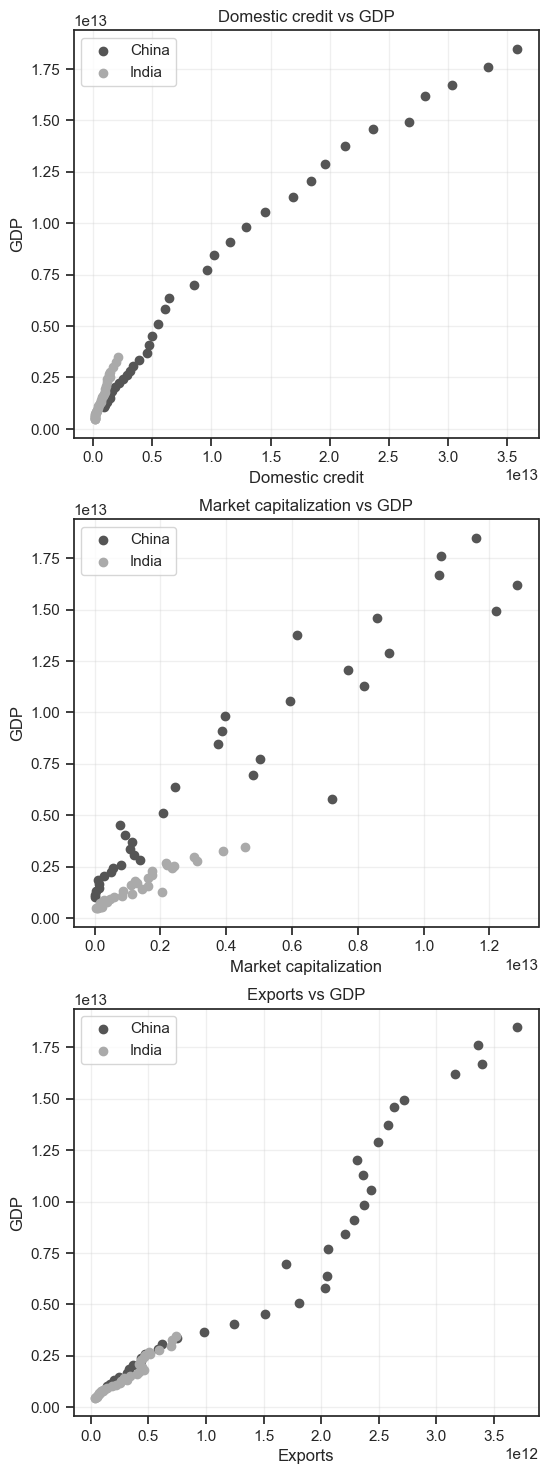

In [85]:
sns.set_theme(style="ticks", font_scale=1)
# Create visualization to understand the data
fig, axes = plt.subplots(3, 1, figsize=(6, 18))


# 2. R&D spending trends
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[0].scatter(data_test_df_temp['Domestic credit']
                       , data_test_df_temp['GDP']
                       , alpha=1
                       , label=country
                       , color = sns.color_palette('gray'
                                                   , len(data_test_df.index.get_level_values(0).unique())
                                                  )[list(data_test_df.index.get_level_values(0).unique()).index(country)]
                      )
    axes[0].set_xlabel('Domestic credit')
    axes[0].set_ylabel('GDP')
    axes[0].set_title('Domestic credit vs GDP')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()


# 3. Scatter plot: R&D vs Profit Margin
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[1].scatter(data_test_df_temp['Market capitalization']
                       , data_test_df_temp['GDP']                       
                       , alpha=1
                       , label=country
                       , color = sns.color_palette('gray'
                                                   , len(data_test_df.index.get_level_values(0).unique())
                                                  )[list(data_test_df.index.get_level_values(0).unique()).index(country)]
                      )
    axes[1].set_xlabel('Market capitalization')
    axes[1].set_ylabel('GDP')
    axes[1].set_title('Market capitalization vs GDP')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

# 4. Boxplot by company
for country in data_test_df.index.get_level_values(0).unique():
    data_test_df_temp = data_test_df.loc[country]
    axes[2].scatter(data_test_df_temp['Exports']
                       , data_test_df_temp['GDP']
                       , alpha=1
                       , label=country
                       , color = sns.color_palette('gray'
                                                   , len(data_test_df.index.get_level_values(0).unique())
                                                  )[list(data_test_df.index.get_level_values(0).unique()).index(country)]
                      )
    axes[2].set_xlabel('Exports')
    axes[2].set_ylabel('GDP')
    axes[2].set_title('Exports vs GDP')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

plt.show()

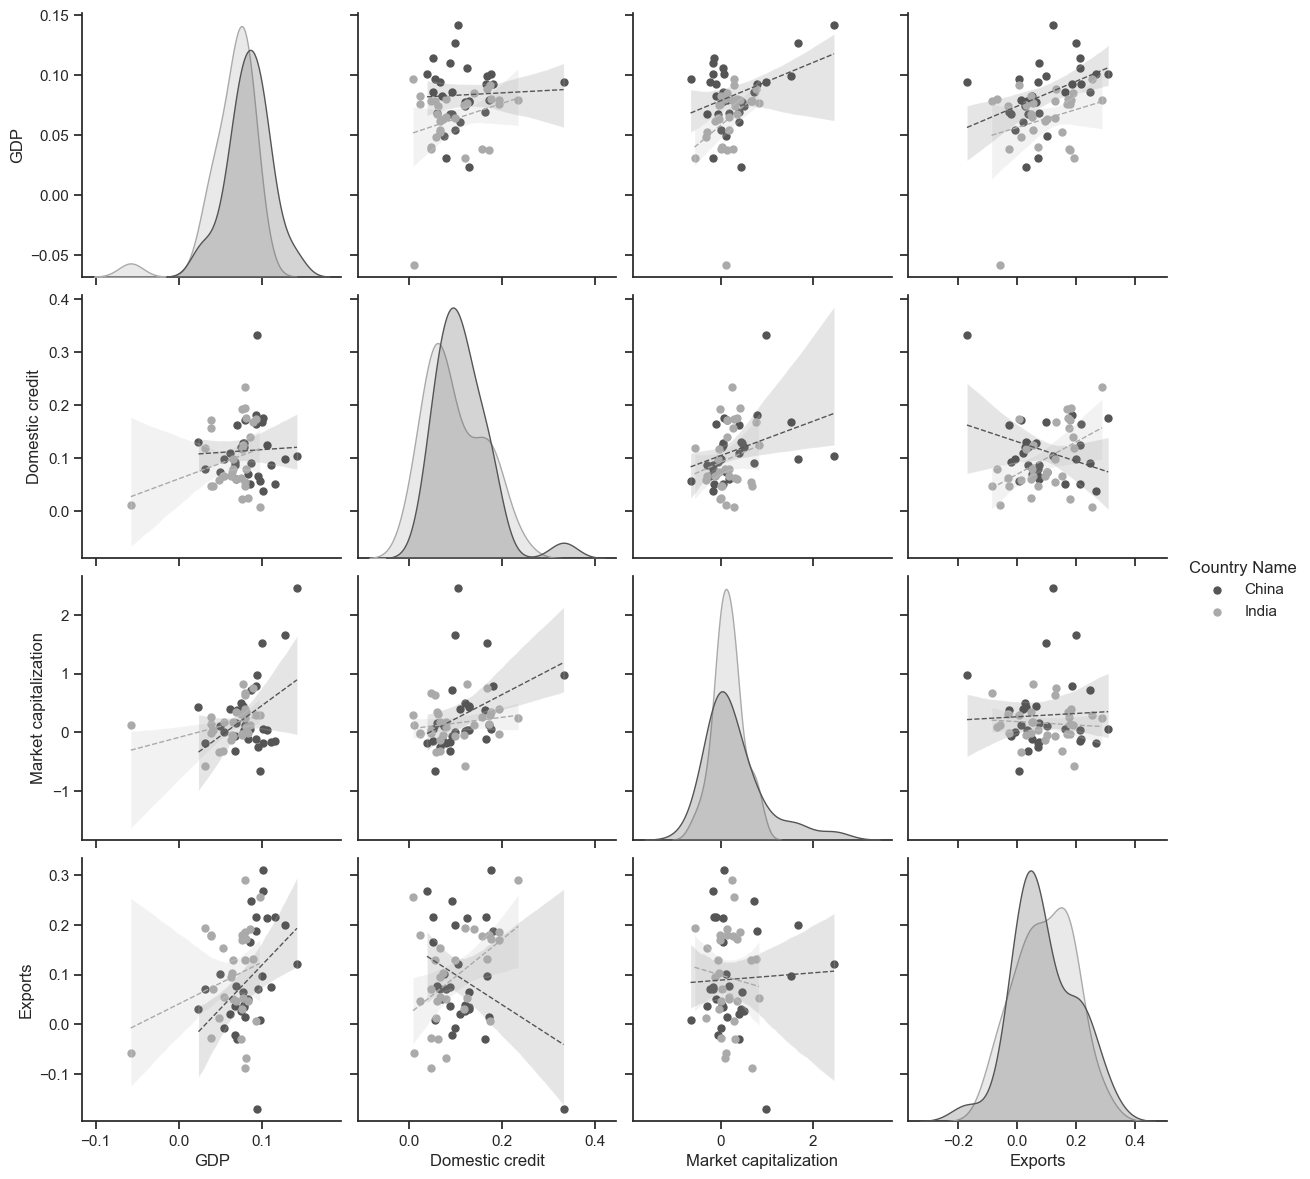

In [118]:
# sns.set_theme(style="ticks", font_scale=1)

sns.pairplot(
    data_test_df.reset_index()[['GDP'
                                , 'Country Name'
                                , 'Domestic credit'
                                , 'Market capitalization'
                                , 'Exports'
                               ]]

    , hue = 'Country Name'
    , palette = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique()))
    , kind='reg'
    , diag_kind = 'kde'
    , height=3
    , plot_kws={'line_kws': {'linestyle': '--'
                             , 'linewidth': 1
                            }
                , 'scatter_kws': {'s': 25
                                  , 'alpha': 1}
               }
    , dropna=True
)


## diff

In [146]:
data_test_df = pd.DataFrame()

for country in data.index.get_level_values(0).unique():
    country_df = data.loc[country].diff(1)
    
    # country_df = data.loc[country].pct_change(1)

    country_df = country_df.iloc[3:].reset_index()
    
    country_df['Country Name'] = country
    data_test_df = pd.concat([data_test_df, country_df])    

data_test_df = data_test_df.set_index(['Country Name', 'Year'])

data_test_df.rename(columns={'Domestic credit to private sector (constant 2015 US$)' : 'Domestic credit'
                             , 'Exports of goods and services (constant 2015 US$)' : 'Exports'
                             , 'Market capitalization of listed domestic companies (constant 2015 US$)' : 'Market capitalization'
                             , 'GDP (constant 2015 US$)' : 'GDP'
                            }, inplace=True)

data_test_df = data_test_df[['GDP'
                             , 'Domestic credit'
                             , 'Market capitalization'
                             , 'Exports'
                            ]].dropna()

In [147]:
data_test_df.to_excel(r'explore_data\_WDI_diff.xlsx', index=False)

In [148]:
# sns.set_theme(style="ticks", font_scale=1)
# # Create visualization to understand the data
# fig, axes = plt.subplots(3, 1, figsize=(6, 18))


# # 2. R&D spending trends
# for country in data_test_df.index.get_level_values(0).unique():
#     data_test_df_temp = data_test_df.loc[country]
#     axes[0].scatter(data_test_df_temp['Domestic credit']
#                        , data_test_df_temp['GDP']
#                        , alpha=1
#                        , label=country
#                        , color = sns.color_palette('gray'
#                                                    , len(data_test_df.index.get_level_values(0).unique())
#                                                   )[list(data_test_df.index.get_level_values(0).unique()).index(country)]
#                       )
#     axes[0].set_xlabel('Domestic credit')
#     axes[0].set_ylabel('GDP')
#     axes[0].set_title('Domestic credit vs GDP')
#     axes[0].grid(True, alpha=0.3)
#     axes[0].legend()


# # 3. Scatter plot: R&D vs Profit Margin
# for country in data_test_df.index.get_level_values(0).unique():
#     data_test_df_temp = data_test_df.loc[country]
#     axes[1].scatter(data_test_df_temp['Market capitalization']
#                        , data_test_df_temp['GDP']                       
#                        , alpha=1
#                        , label=country
#                        , color = sns.color_palette('gray'
#                                                    , len(data_test_df.index.get_level_values(0).unique())
#                                                   )[list(data_test_df.index.get_level_values(0).unique()).index(country)]
#                       )
#     axes[1].set_xlabel('Market capitalization')
#     axes[1].set_ylabel('GDP')
#     axes[1].set_title('Market capitalization vs GDP')
#     axes[1].grid(True, alpha=0.3)
#     axes[1].legend()

# # 4. Boxplot by company
# for country in data_test_df.index.get_level_values(0).unique():
#     data_test_df_temp = data_test_df.loc[country]
#     axes[2].scatter(data_test_df_temp['Exports']
#                        , data_test_df_temp['GDP']
#                        , alpha=1
#                        , label=country
#                        , color = sns.color_palette('gray'
#                                                    , len(data_test_df.index.get_level_values(0).unique())
#                                                   )[list(data_test_df.index.get_level_values(0).unique()).index(country)]
#                       )
#     axes[2].set_xlabel('Exports')
#     axes[2].set_ylabel('GDP')
#     axes[2].set_title('Exports vs GDP')
#     axes[2].grid(True, alpha=0.3)
#     axes[2].legend()

# plt.show()

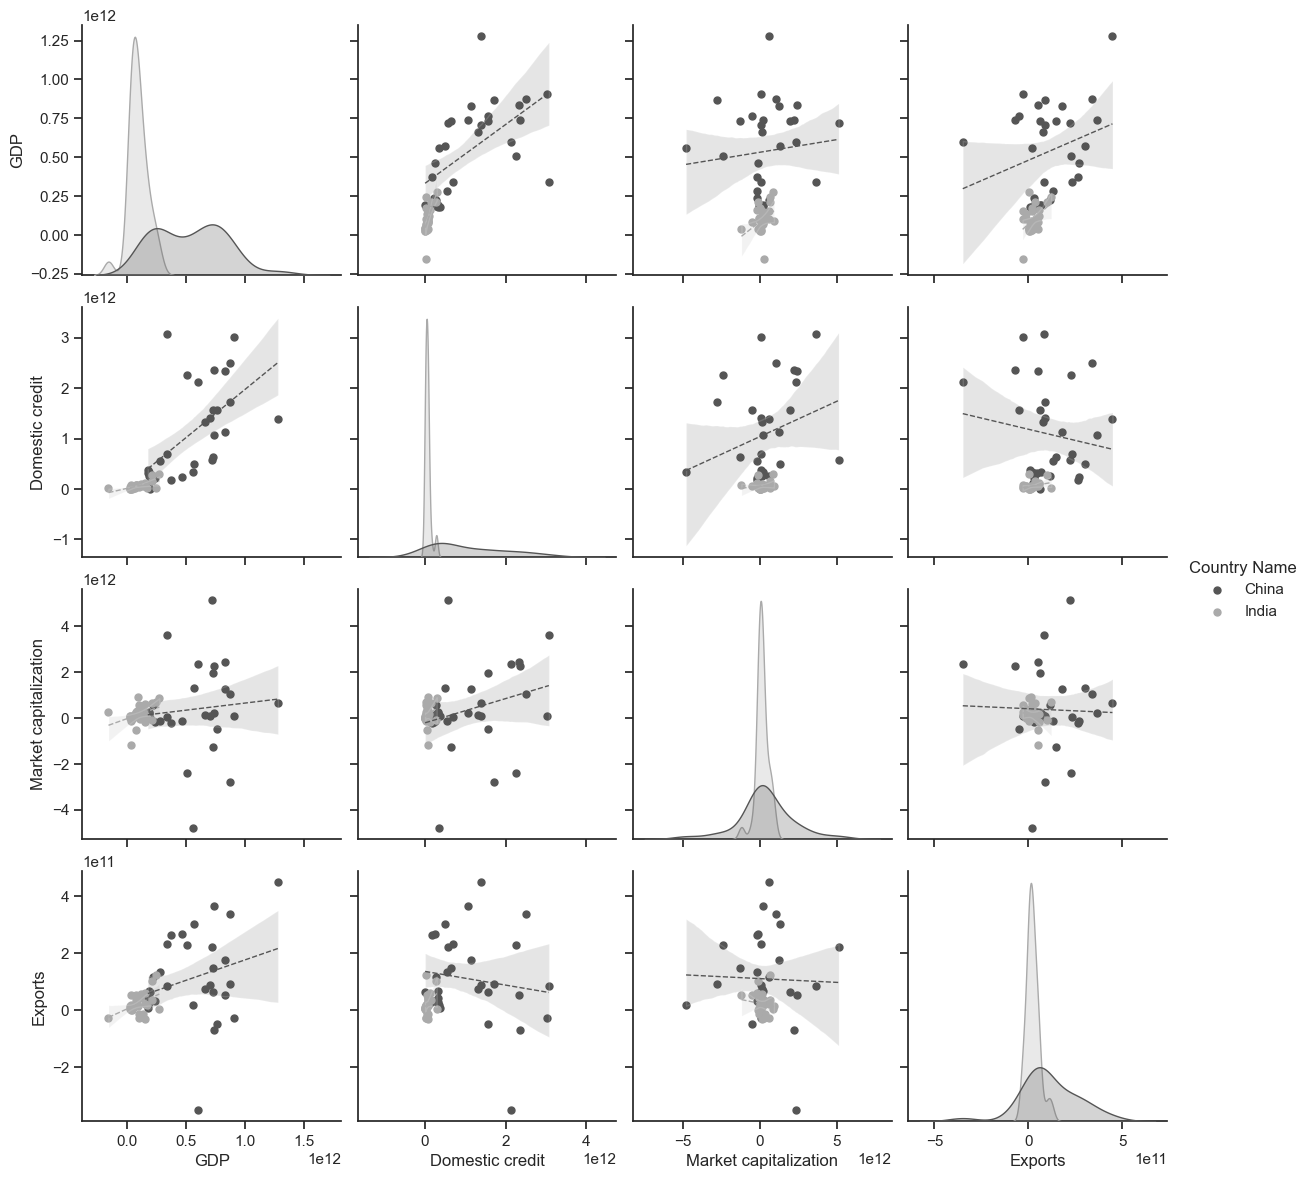

In [149]:
# sns.set_theme(style="ticks", font_scale=1)

sns.pairplot(
    data_test_df.reset_index()[['GDP'
                                , 'Country Name'
                                , 'Domestic credit'
                                , 'Market capitalization'
                                , 'Exports'
                               ]]
    
    , hue = 'Country Name'
    , palette = sns.color_palette('gray', len(data_test_df.index.get_level_values(0).unique()))
    , kind='reg'
    , diag_kind = 'kde'
    , height=3
    , plot_kws={'line_kws': {'linestyle': '--'
                             , 'linewidth': 1
                            }
                , 'scatter_kws': {'s': 25
                                  , 'alpha': 1}
               }
    , dropna=True
)


# model

In [150]:
# Prepare variables
# Note: linearmodels requires explicit addition of constant for some models
X = data_test_df[['Domestic credit'
                  , 'Market capitalization'
                  , 'Exports'
                 ]]
y = data_test_df['GDP']

# Add constant for models that need it
X_with_const = sm.add_constant(X)

print("="*60)
print("PANEL DATA REGRESSION RESULTS")
print("="*60)

# 1. POOLED OLS (ignores panel structure)
print("\n1. POOLED OLS MODEL")
print("-"*40)
pooled_model = PooledOLS(y, X_with_const)
pooled_results = pooled_model.fit(cov_type='robust')
print(pooled_results)

# 2. FIXED EFFECTS MODEL (entity effects)
print("\n2. FIXED EFFECTS MODEL")
print("-"*40)
# entity_effects=True includes fixed effects for each company
fe_model = PanelOLS(y, X, entity_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results)

# 3. RANDOM EFFECTS MODEL
print("\n3. RANDOM EFFECTS MODEL")
print("-"*40)
re_model = RandomEffects(y, X_with_const)
re_results = re_model.fit(cov_type='robust')
print(re_results)

# 4. TWO-WAY FIXED EFFECTS (entity + time effects)
print("\n4. TWO-WAY FIXED EFFECTS MODEL")
print("-"*40)
twfe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
twfe_results = twfe_model.fit(cov_type='clustered', cluster_entity=True)
print(twfe_results)

PANEL DATA REGRESSION RESULTS

1. POOLED OLS MODEL
----------------------------------------
                          PooledOLS Estimation Summary                          
Dep. Variable:                    GDP   R-squared:                        0.7208
Estimator:                  PooledOLS   R-squared (Between):              0.9632
No. Observations:                  64   R-squared (Within):               0.4488
Date:                Fri, Mar 13 2026   R-squared (Overall):              0.7208
Time:                        17:55:24   Log-likelihood                   -1742.4
Cov. Estimator:                Robust                                           
                                        F-statistic:                      51.626
Entities:                           2   P-value                           0.0000
Avg Obs:                       32.000   Distribution:                    F(3,60)
Min Obs:                       32.000                                           
Max Obs:         

In [92]:
fe_model = PanelOLS(y, X)
fe_results = fe_model.fit()
print(fe_results)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    GDP   R-squared:                        0.8341
Estimator:                   PanelOLS   R-squared (Between):              0.9754
No. Observations:                  68   R-squared (Within):               0.4186
Date:                Fri, Mar 13 2026   R-squared (Overall):              0.8341
Time:                        17:37:38   Log-likelihood                   -1856.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      108.90
Entities:                           2   P-value                           0.0000
Avg Obs:                       34.000   Distribution:                    F(3,65)
Min Obs:                       34.000                                           
Max Obs:                       34.000   F-statistic (robust):             108.90
                            

In [93]:
fe_model = PanelOLS(y, X, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    GDP   R-squared:                        0.8300
Estimator:                   PanelOLS   R-squared (Between):              0.9387
No. Observations:                  68   R-squared (Within):               0.4781
Date:                Fri, Mar 13 2026   R-squared (Overall):              0.8218
Time:                        17:37:38   Log-likelihood                   -1819.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      50.434
Entities:                           2   P-value                           0.0000
Avg Obs:                       34.000   Distribution:                    F(3,31)
Min Obs:                       34.000                                           
Max Obs:                       34.000   F-statistic (robust):          6.294e+47
                            

In [94]:
fe_model = PanelOLS(y, X, entity_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    GDP   R-squared:                        0.5265
Estimator:                   PanelOLS   R-squared (Between):              0.8296
No. Observations:                  68   R-squared (Within):               0.5265
Date:                Fri, Mar 13 2026   R-squared (Overall):              0.7527
Time:                        17:37:38   Log-likelihood                   -1845.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      23.351
Entities:                           2   P-value                           0.0000
Avg Obs:                       34.000   Distribution:                    F(3,63)
Min Obs:                       34.000                                           
Max Obs:                       34.000   F-statistic (robust):          1.008e+19
                            

In [95]:
X = data_test_df[['Bank deposits'
                  , 'Domestic credit'
                  , 'Exports'
                  , 'Market capitalization'
                 ]]
y = data_test_df['GDP']

KeyError: "['Bank deposits'] not in index"

In [ ]:
data_test_df = data_test_df.reset_index()

In [ ]:
# data_test_df

In [ ]:
sns.set_theme(style="ticks", font_scale=1.5)

sns.pairplot(
    data_test_df[['Bank deposits'
                  , 'Domestic credit'
                  , 'Exports'
                  , 'Market capitalization'
                  , 'GDP'
                  # , 'Country Name'
                 ]]
    
    # , x_vars=['Value-traded'
    #           , 'Turnover'
    #           , 'MarCap to GDP'
              
    #           , 'Deposits to GDP'
    #           , 'Broad money'
    #           , 'Credit to private'
    #          ]
    # , y_vars=["Growth rate"]
    # , hue = 'Country Name'
    
    , kind='reg'
    , height=4
    , plot_kws={'line_kws': {'linestyle': '--'
                             , 'linewidth': 1
                            }
                , 'scatter_kws': {'s': 25
                                  , 'alpha': 0.3}
               }
    , dropna=True
)


In [ ]:
df = data_test_df[['GDP', 'Country Name']]

In [ ]:
custom_order = list(df.groupby('Country Name').mean().sort_values('GDP').index)

In [ ]:
df['Country Name'] = pd.Categorical(df['Country Name'], categories=custom_order, ordered=True)

# 4. Sort the DataFrame by the 'Size' column
# This will now use the custom categorical order
df = df.sort_values(by='Country Name')

In [ ]:
df = df[~df['Country Name'].isin(['United States', 'China'])]

In [ ]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['GDP'].quantile(0.25)
Q3 = df['GDP'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.75 * IQR
upper_bound = Q3 + 1.75 * IQR

# Filter the DataFrame to keep only non-outlier rows
df = df[(df['GDP'] >= lower_bound) & (df['GDP'] <= upper_bound)]

In [ ]:
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0)})

# # Create the data
# rs = np.random.RandomState(1979)
# x = rs.randn(1400)
# g = np.tile(list("ABCDEFGHIJKLMN"), 100)
# df = pd.DataFrame(dict(x=x, g=g))
# m = df.g.map(ord)
# df["GDP"] += m

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(21, rot=-.25, light=.7)
g = sns.FacetGrid(df, row="Country Name", hue="Country Name", aspect=15, height=0.75, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "GDP",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "GDP", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "GDP")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)